# IEEE Fraud Detection — EDA & Data Cleaning
## Dziennik decyzji

### 0. Wczytanie danych
- train_transaction: 590,540 wierszy × 394 kolumny
- train_identity: 144,233 wierszy × 41 kolumny

### 1. Scalenie (merge)
- Klucz: `TransactionID`, left join (nie każda transakcja ma dane identity)
- Po scaleniu: train 590,540 × 434
- Tylko ~24% transakcji train ma dane identity — to strukturalny brak, nie błąd

### 2. Zmienna celu (isFraud)
- Fraud rate: **3.50%** (20,663 fraudów na 590,540 transakcji)
- ⚠️ Silna nierównowaga klas — modele muszą używać AUC-ROC zamiast accuracy

### 3. Brakujące dane
- 20 kolumn bez żadnych braków
- 74 kolumny z >80% NaN
- Grupy kolumn:
  - **C (counts):** 0% NaN — gotowe do użycia
  - **identity:** min 75.6% NaN — strukturalny brak (tylko 24% transakcji ma identity)
  - **D (deltas):** mediana 76.2% NaN
  - **M (flags):** mediana 47.7% NaN
  - **V (Vesta):** mediana 47.3% NaN, bardzo zróżnicowane

### 4. Decyzja — kolumny z >80% NaN
**D i identity z >80% NaN → ZACHOWUJEMY** (fraud rate 3–5x wyższy gdy wartość istnieje, np. D7: 14.88% vs 2.70%)
Strategia: tworzymy binarne flagi `_isnan` — sam fakt posiadania wartości jest sygnałem.

**V-kolumny z >80% NaN → decyzja na podstawie korelacji wartości z fraudem:**
- Próg usunięcia: |korelacja| < 0.05 AND różnica fraud rate < 2%
- Zachowujemy kolumny z korelacją ≥ 0.05 (mają realny sygnał, np. V158=0.278, V156=0.276)

### 5. Usunięcie i flagi
- Usunięto 24 V-kolumny z >80% NaN i |korelacja| < 0.05
- Zachowano 23 V-kolumny z >80% NaN ale z realnym sygnałem (korelacja ≥ 0.05)
- Dla D, identity i dist2 z >80% NaN utworzono binarne flagi `_isnan`
  zamiast usuwać — sam brak wartości jest sygnałem fraudowym

### 6. Flagi _isnan — weryfikacja
- D7_isnan=0 (wartość istnieje): fraud rate 14.88%
- D7_isnan=1 (brak wartości):    fraud rate 2.70%
- Potwierdza że flagi niosą realny sygnał

### 7. Encoding zmiennych kategorycznych
- **M-kolumny:** T→1, F→0, NaN→-1
- **Proste kategoryczne** (ProductCD, card4, card6 itd.): label encoding fitowany na train
- **Email domains:** zgrupowane → gmail/yahoo/microsoft/anonymous/high_risk/other/missing
  - Sygnał: protonmail.com ma 40.79% fraud rate jako purchaser, 95.12% jako recipient
- **id_30:** wyciągnięty sam OS (android/ios/windows/mac/linux/other)
- **id_31:** uproszczony do rodziny przeglądarki (chrome/firefox/safari/edge/ie/samsung/other)
- **id_33, DeviceInfo:** zastąpione flagą `_present` — zbyt wiele unikalnych wartości (260 i 1786)
- **id_23:** proxy type — label encoding (IP_PROXY:ANONYMOUS ma 13.73% fraud rate)

### 8. Feature engineering
- **TransactionDT** → wyciągnięto `hour` (0–23) i `dayofweek` (0–6), oryginalna kolumna usunięta
  - Fraud rate wyraźnie wyższy rano (5–9), max 10.61% o godz. 7
  - Możliwe wyjaśnienie: właściciel karty śpi i nie widzi powiadomień
- **TransactionAmt** → dodano `log_TransactionAmt` (redukcja skośności z 14.37 → 0.49)
- **email_match** → flaga czy P_emaildomain == R_emaildomain (6.45% vs 2.13%)

### 9. Imputacja
- Mediany liczone i aplikowane wyłącznie na train
- (zapobieganie data leakage)

### 10. Wynik końcowy
- train_cleaned.csv: 590,540 wierszy × 440 kolumn, 0 NaN
- Fraud rate zachowany: 3.50%

### 11. Podział Out-Of-Time (60/20/20)
- Sortowanie po TransactionID (proxy dla czasu)
- train: 354,324 wierszy | fraud rate: 3.38%
- valid: 118,108 wierszy | fraud rate: 3.90%
- test:  118,108 wierszy | fraud rate: 3.44%
- Seed: SEED = 123

---
## Ważne uwagi dla modelujących

1. **Nierównowaga klas (3.5% fraudów)**
   - NIE używać accuracy jako metryki — model który zawsze mówi "legalna" ma 96.5% accuracy
   - Używać AUC-ROC
   - Rozważyć: `class_weight='balanced'` lub SMOTE z biblioteki imbalanced-learn

2. **Standaryzacja**
   - Sieci neuronowe wymagają standaryzacji (StandardScaler lub MinMaxScaler)
   - Drzewa decyzyjne (XGBoost, LightGBM, Random Forest) — standaryzacja niekonieczna

3. **Kolumny _isnan**
   - Nie usuwać — niosą realny sygnał (D7: fraud rate 14.88% gdy wartość istnieje vs 2.70% gdy NaN)

4. **Podział Out-Of-Time**
   - Train/valid/test są posortowane chronologicznie — model zawsze "przewiduje przyszłość"
   - Odzwierciedla realne warunki produkcyjne

5. **Kolumna isFraud**
   - Dostępna w train_model, valid_model, test_model
   - X_train/X_valid/X_test nie zawierają isFraud ani TransactionID

---
## EDA

### Wykres 1 — Rozkład zmiennej celu (isFraud)
- 569,877 legalnych transakcji (96.5%) vs 20,663 fraudów (3.5%)
- Proporcja ~28:1 — silna nierównowaga klas
- **Wniosek dla modelujących:** accuracy jest bezużyteczną metryką —
  model przewidujący zawsze "legalna" osiąga 96.5% accuracy bez żadnej wiedzy.
  Używać AUC-ROC, F1 lub precision-recall curve.

### Wykres 2 — Rozkład kwoty transakcji (TransactionAmt)
- Rozkład silnie prawostronnie skośny — większość transakcji to małe kwoty (poniżej 200 USD)
- Mediany kwot fraud i legalnych transakcji są zbliżone — sama kwota nie jest silnym predyktorem
- Outliery sięgają powyżej 10,000 USD
- Log-transformacja redukuje skośność z 14.37 do 0.49 — krytyczne dla sieci neuronowych
- **Wniosek:** TransactionAmt sam w sobie słaby sygnał, ale log_TransactionAmt jako feature jest ważny

### Wykres 3 — Fraud rate wg godziny transakcji
- Wyraźny szczyt fraudów między godziną 5 a 10 rano (max 10.61% o godz. 7)
- W godzinach 11–18 fraud rate spada poniżej baseline (2–3%)
- Możliwe wyjaśnienie: fraudy wykonywane gdy właściciel karty śpi i nie widzi powiadomień
- **Wniosek:** zmienna `hour` jest istotnym predyktorem — warto zachować w modelu

### Wykres 4 — Fraud rate wg kategorii produktu i typu karty
- **ProductCD:**
  - Kategoria C ma 11.7% fraudów — ponad 3x powyżej baseline
  - Kategoria W (najczęstsza) ma tylko 2.0% — poniżej baseline
- **card6:**
  - Karty kredytowe (credit): 6.7% fraudów — prawie 2x powyżej baseline
  - Karty debetowe (debit): 2.4% — poniżej baseline
  - **Wniosek:** kartą kredytową łatwiej dokonać fraudu (brak natychmiastowego obciążenia konta)

### Wykres 5 — Fraud rate wg domeny email
- protonmail.com jako purchaser → 40.79% fraudów, jako recipient → 95.12%
- Anonimowe skrzynki emailowe = silna czerwona flaga
- id_23 (proxy IP): IP_PROXY:ANONYMOUS ma 13.73% fraud rate

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# --- Globalne ziarno losowości ---
SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path(".")

print("Wczytuję train_transaction...")
train_transaction = pd.read_csv(DATA_DIR / "train_transaction.csv")
print(f"  OK — {train_transaction.shape}")

print("Wczytuję train_identity...")
train_identity = pd.read_csv(DATA_DIR / "train_identity.csv")
print(f"  OK — {train_identity.shape}")

print("\nPierwsze kolumny train_transaction:")
print(train_transaction.columns[:20].tolist())

print("\nPierwsze kolumny train_identity:")
print(train_identity.columns[:20].tolist())


Wczytuję train_transaction...
  OK — (590540, 394)
Wczytuję train_identity...
  OK — (144233, 41)

Pierwsze kolumny train_transaction:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3']

Pierwsze kolumny train_identity:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19']


In [2]:
# Scalanie po TransactionID (left join — nie każda transakcja ma identity)
train = train_transaction.merge(train_identity, on="TransactionID", how="left")

print("Po scaleniu:")
print(f"  train: {train.shape}")

print(f"\nTransakcje z danymi identity:")
print(f"  train: {train_identity.shape[0]:,} z {train_transaction.shape[0]:,} ({train_identity.shape[0]/train_transaction.shape[0]*100:.1f}%)")

print("\n=== ZMIENNA CELU ===")
fraud_counts = train["isFraud"].value_counts()
print(fraud_counts)
print(f"\nFraud rate: {train['isFraud'].mean()*100:.2f}%")


Po scaleniu:
  train: (590540, 434)

Transakcje z danymi identity:
  train: 144,233 z 590,540 (24.4%)

=== ZMIENNA CELU ===
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


In [3]:
# Procent brakujących wartości dla każdej kolumny
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)

# Podział na grupy
print("=== BRAKUJĄCE DANE — PODSUMOWANIE ===")
print(f"Kolumny bez żadnych braków:   {(missing == 0).sum()}")
print(f"Kolumny z 0–20% NaN:          {((missing > 0) & (missing <= 20)).sum()}")
print(f"Kolumny z 20–50% NaN:         {((missing > 20) & (missing <= 50)).sum()}")
print(f"Kolumny z 50–80% NaN:         {((missing > 50) & (missing <= 80)).sum()}")
print(f"Kolumny z >80% NaN:           {(missing > 80).sum()}")

print("\n=== TOP 20 KOLUMN Z NAJWIĘKSZĄ LICZBĄ NaN ===")
print(missing.head(20).round(1).to_string())

print("\n=== GRUPY KOLUMN — % NaN ===")
for prefix, label in [("V", "V (Vesta)"), ("D", "D (deltas)"), 
                       ("id_", "identity"), ("C", "C (counts)"), ("M", "M (flags)")]:
    cols = [c for c in train.columns if c.startswith(prefix)]
    if cols:
        m = missing[cols]
        print(f"\n{label} ({len(cols)} kolumn):")
        print(f"  min NaN: {m.min():.1f}%  |  max NaN: {m.max():.1f}%  |  mediana NaN: {m.median():.1f}%")

=== BRAKUJĄCE DANE — PODSUMOWANIE ===
Kolumny bez żadnych braków:   20
Kolumny z 0–20% NaN:          162
Kolumny z 20–50% NaN:         38
Kolumny z 50–80% NaN:         140
Kolumny z >80% NaN:           74

=== TOP 20 KOLUMN Z NAJWIĘKSZĄ LICZBĄ NaN ===
id_24    99.2
id_25    99.1
id_07    99.1
id_08    99.1
id_21    99.1
id_26    99.1
id_27    99.1
id_23    99.1
id_22    99.1
dist2    93.6
D7       93.4
id_18    92.4
D13      89.5
D14      89.5
D12      89.0
id_03    88.8
id_04    88.8
D6       87.6
id_33    87.6
id_10    87.3

=== GRUPY KOLUMN — % NaN ===

V (Vesta) (339 kolumn):
  min NaN: 0.0%  |  max NaN: 86.1%  |  mediana NaN: 47.3%

D (deltas) (17 kolumn):
  min NaN: 0.2%  |  max NaN: 93.4%  |  mediana NaN: 76.2%

identity (38 kolumn):
  min NaN: 75.6%  |  max NaN: 99.2%  |  mediana NaN: 82.4%

C (counts) (14 kolumn):
  min NaN: 0.0%  |  max NaN: 0.0%  |  mediana NaN: 0.0%

M (flags) (9 kolumn):
  min NaN: 28.7%  |  max NaN: 59.3%  |  mediana NaN: 47.7%


In [4]:
high_missing_cols = missing[missing > 80].index.tolist()

print(f"Kolumny z >80% NaN: {len(high_missing_cols)}")
print(f"\nZ jakich grup pochodzą:")
for prefix, label in [("V", "V"), ("D", "D"), ("id_", "identity"), ("C", "C"), ("M", "M"), ("dist", "dist")]:
    cols = [c for c in high_missing_cols if c.startswith(prefix)]
    if cols:
        print(f"  {label}: {len(cols)} kolumn — {cols}")

print("\n=== FRAUD RATE dla kolumn z >80% NaN (gdy wartość JEST dostępna) ===")
print("(czy sam fakt że kolumna ma wartość koreluje z fraudem?)\n")

results = []
for col in high_missing_cols:
    has_value = train[col].notna()
    fraud_with    = train.loc[has_value, "isFraud"].mean() * 100
    fraud_without = train.loc[~has_value, "isFraud"].mean() * 100
    results.append({
        "kolumna": col,
        "% NaN": missing[col].round(1),
        "fraud gdy ma wartość": round(fraud_with, 2),
        "fraud gdy NaN": round(fraud_without, 2),
        "różnica": round(fraud_with - fraud_without, 2)
    })

df_results = pd.DataFrame(results).sort_values("różnica", key=abs, ascending=False)
print(df_results.head(20).to_string(index=False))

Kolumny z >80% NaN: 74

Z jakich grup pochodzą:
  V: 47 kolumn — ['V142', 'V158', 'V140', 'V162', 'V141', 'V161', 'V157', 'V146', 'V156', 'V155', 'V154', 'V153', 'V149', 'V147', 'V148', 'V163', 'V139', 'V138', 'V160', 'V151', 'V152', 'V145', 'V144', 'V143', 'V159', 'V164', 'V165', 'V166', 'V150', 'V337', 'V333', 'V336', 'V335', 'V334', 'V338', 'V339', 'V324', 'V332', 'V325', 'V330', 'V329', 'V328', 'V327', 'V326', 'V322', 'V323', 'V331']
  D: 7 kolumn — ['D7', 'D13', 'D14', 'D12', 'D6', 'D9', 'D8']
  identity: 19 kolumn — ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'id_18', 'id_03', 'id_04', 'id_33', 'id_10', 'id_09', 'id_30', 'id_32', 'id_34', 'id_14']
  dist: 1 kolumn — ['dist2']

=== FRAUD RATE dla kolumn z >80% NaN (gdy wartość JEST dostępna) ===
(czy sam fakt że kolumna ma wartość koreluje z fraudem?)

kolumna  % NaN  fraud gdy ma wartość  fraud gdy NaN  różnica
     D7   93.4                 14.88           2.70    12.18
    D12   89.0       

In [5]:
v_high_missing = [c for c in high_missing_cols if c.startswith("V")]

print(f"V-kolumny z >80% NaN: {len(v_high_missing)}")
print(f"Zakres: {sorted(v_high_missing, key=lambda x: int(x[1:]))}\n")

# Fraud rate gdy wartość dostępna vs NaN
results_v = []
for col in v_high_missing:
    has_value = train[col].notna()
    fraud_with    = train.loc[has_value, "isFraud"].mean() * 100
    fraud_without = train.loc[~has_value, "isFraud"].mean() * 100
    # Korelacja wartości z fraudem (tylko gdzie wartość istnieje)
    corr = train.loc[has_value, [col, "isFraud"]].corr().iloc[0, 1]
    results_v.append({
        "kolumna": col,
        "% NaN": round(missing[col], 1),
        "fraud gdy wartość": round(fraud_with, 2),
        "fraud gdy NaN": round(fraud_without, 2),
        "różnica": round(fraud_with - fraud_without, 2),
        "korelacja wartości z fraudem": round(corr, 3)
    })

df_v = pd.DataFrame(results_v).sort_values("różnica", key=abs, ascending=False)
print(df_v.to_string(index=False))

V-kolumny z >80% NaN: 47
Zakres: ['V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339']

kolumna  % NaN  fraud gdy wartość  fraud gdy NaN  różnica  korelacja wartości z fraudem
   V331   86.1               4.48           3.34     1.14                        -0.022
   V332   86.1               4.48           3.34     1.14                        -0.023
   V337   86.1               4.48           3.34     1.14                        -0.006
   V333   86.1               4.48           3.34     1.14                        -0.024
   V336   86.1               4.48           3.34     1.14                        -0.002
   V335   86.1               4.48           3.34     1.14    

In [6]:
# Decyzja dla V-kolumn z >80% NaN
v_to_drop = [r["kolumna"] for _, r in df_v.iterrows() 
             if abs(r["korelacja wartości z fraudem"]) < 0.05 and r["różnica"] < 2]

v_to_keep = [r["kolumna"] for _, r in df_v.iterrows() 
             if r["kolumna"] not in v_to_drop]

print(f"V-kolumny z >80% NaN do USUNIĘCIA ({len(v_to_drop)}):")
print(sorted(v_to_drop, key=lambda x: int(x[1:])))

print(f"\nV-kolumny z >80% NaN do ZACHOWANIA ({len(v_to_keep)}):")
print(sorted(v_to_keep, key=lambda x: int(x[1:])))

# Wszystkie kolumny do usunięcia (tylko V, D i identity zostawiamy z flagą)
cols_to_drop = v_to_drop

print(f"\nŁącznie kolumn do usunięcia: {len(cols_to_drop)}")
print(f"Kolumny przed usunięciem: {train.shape[1]}")
print(f"Kolumny po usunięciu:     {train.shape[1] - len(cols_to_drop)}")

V-kolumny z >80% NaN do USUNIĘCIA (24):
['V138', 'V143', 'V161', 'V163', 'V164', 'V166', 'V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339']

V-kolumny z >80% NaN do ZACHOWANIA (23):
['V139', 'V140', 'V141', 'V142', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V162', 'V165']

Łącznie kolumn do usunięcia: 24
Kolumny przed usunięciem: 434
Kolumny po usunięciu:     410


In [7]:
# === USUNIĘCIE kolumn V bez sygnału ===
train = train.drop(columns=cols_to_drop)
print(f"Po usunięciu V-kolumn bez sygnału: train {train.shape}")

# === FLAGI _isnan dla D i identity z >80% NaN ===
d_high    = [c for c in high_missing_cols if c.startswith("D") and c in train.columns]
id_high   = [c for c in high_missing_cols if c.startswith("id_") and c in train.columns]
dist_high = [c for c in high_missing_cols if c.startswith("dist") and c in train.columns]

flag_cols = d_high + id_high + dist_high
print(f"\nTworzymy flagi _isnan dla {len(flag_cols)} kolumn:")
print(f"  D:        {d_high}")
print(f"  identity: {id_high}")
print(f"  dist:     {dist_high}")

for col in flag_cols:
    train[f"{col}_isnan"] = train[col].isnull().astype(int)

print(f"\nPo dodaniu flag: train {train.shape}")

# Weryfikacja
print(f"\nWeryfikacja D7_isnan:")
print(train.groupby("D7_isnan")["isFraud"].mean().round(4) * 100)


Po usunięciu V-kolumn bez sygnału: train (590540, 410)

Tworzymy flagi _isnan dla 27 kolumn:
  D:        ['D7', 'D13', 'D14', 'D12', 'D6', 'D9', 'D8']
  identity: ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'id_18', 'id_03', 'id_04', 'id_33', 'id_10', 'id_09', 'id_30', 'id_32', 'id_34', 'id_14']
  dist:     ['dist2']

Po dodaniu flag: train (590540, 437)

Weryfikacja D7_isnan:
D7_isnan
0    14.88
1     2.70
Name: isFraud, dtype: float64


In [8]:
# === PRZEGLĄD ZMIENNYCH KATEGORYCZNYCH ===
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
print(f"Kolumny kategoryczne: {len(cat_cols)}")
print(f"{cat_cols}\n")

for col in cat_cols:
    n_unique = train[col].nunique()
    n_missing = train[col].isnull().mean() * 100
    fraud_by_cat = train.groupby(col)["isFraud"].mean().sort_values(ascending=False) * 100
    print(f"--- {col} ---")
    print(f"  unikalne wartości: {n_unique}  |  NaN: {n_missing:.1f}%")
    print(f"  top fraud rate:")
    print(fraud_by_cat.head(5).round(2).to_string())
    print()

Kolumny kategoryczne: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

--- ProductCD ---
  unikalne wartości: 5  |  NaN: 0.0%
  top fraud rate:
ProductCD
C    11.69
S     5.90
H     4.77
R     3.78
W     2.04

--- card4 ---
  unikalne wartości: 4  |  NaN: 0.3%
  top fraud rate:
card4
discover            7.73
visa                3.48
mastercard          3.43
american express    2.87

--- card6 ---
  unikalne wartości: 4  |  NaN: 0.3%
  top fraud rate:
card6
credit             6.68
debit              2.43
charge card        0.00
debit or credit    0.00

--- P_emaildomain ---
  unikalne wartości: 59  |  NaN: 16.0%
  top fraud rate:
P_emaildomain
protonmail.com    40.79
mail.com          18.96
outlook.es        13.01
aim.com           12.70
outlook.com    

In [9]:
# === ENCODING KATEGORYCZNYCH ===

# --- M-kolumny: T/F → 1/0, NaN → -1 ---
m_cols = [c for c in train.columns if c.startswith("M")]
for col in m_cols:
    train[col] = train[col].map({"T": 1, "F": 0}).fillna(-1).astype(int)
print(f"M-kolumny ({len(m_cols)}) → zakodowane jako 1/0/-1")

# --- Proste binarne i małe kategoryczne: label encoding ---
simple_cats = ["ProductCD", "card4", "card6", "DeviceType",
               "id_12", "id_15", "id_16", "id_27", "id_28",
               "id_29", "id_34", "id_35", "id_36", "id_37", "id_38"]
simple_cats = [c for c in simple_cats if c in train.columns]

for col in simple_cats:
    train[col] = pd.Categorical(train[col]).codes
print(f"Proste kategoryczne ({len(simple_cats)}) → label encoding")

# --- Email domains ---
def group_email(domain):
    if pd.isna(domain): return "missing"
    d = str(domain).lower()
    if "gmail" in d:   return "gmail"
    if "yahoo" in d:   return "yahoo"
    if "hotmail" in d or "outlook" in d or "live" in d: return "microsoft"
    if "anonymous" in d: return "anonymous"
    if "protonmail" in d or "mail.com" in d: return "high_risk"
    return "other"

for col in ["P_emaildomain", "R_emaildomain"]:
    train[col] = train[col].apply(group_email)
    train[col] = pd.Categorical(train[col]).codes
print("Email domains → zgrupowane")

# --- id_30: OS ---
def extract_os(val):
    if pd.isna(val): return "missing"
    val = str(val).lower()
    if "android" in val: return "android"
    if "ios" in val:     return "ios"
    if "windows" in val: return "windows"
    if "mac" in val:     return "mac"
    if "linux" in val:   return "linux"
    return "other"

train["id_30"] = train["id_30"].apply(extract_os)
train["id_30"] = pd.Categorical(train["id_30"]).codes
print("id_30 → uproszczony do OS")

# --- id_31: przeglądarka ---
def extract_browser(val):
    if pd.isna(val): return "missing"
    val = str(val).lower()
    if "chrome" in val:   return "chrome"
    if "firefox" in val or "mozilla" in val: return "firefox"
    if "safari" in val:   return "safari"
    if "edge" in val:     return "edge"
    if "ie" in val or "internet explorer" in val: return "ie"
    if "samsung" in val:  return "samsung"
    return "other"

train["id_31"] = train["id_31"].apply(extract_browser)
train["id_31"] = pd.Categorical(train["id_31"]).codes
print("id_31 → uproszczony do rodziny przeglądarki")

# --- id_33, DeviceInfo → flaga obecności ---
for col in ["id_33", "DeviceInfo"]:
    if col in train.columns:
        train[f"{col}_present"] = train[col].notna().astype(int)
        train = train.drop(columns=[col])
print("id_33, DeviceInfo → zastąpione flagą _present")

# --- id_23 ---
train["id_23"] = pd.Categorical(train["id_23"]).codes
print("id_23 → label encoding")

print(f"\nPo encodingu: train {train.shape}")

remaining_cats = train.select_dtypes(include=["object"]).columns.tolist()
print(f"\nPozostałe kolumny object (powinno być 0): {remaining_cats}")


M-kolumny (9) → zakodowane jako 1/0/-1
Proste kategoryczne (15) → label encoding
Email domains → zgrupowane
id_30 → uproszczony do OS
id_31 → uproszczony do rodziny przeglądarki
id_33, DeviceInfo → zastąpione flagą _present
id_23 → label encoding

Po encodingu: train (590540, 437)

Pozostałe kolumny object (powinno być 0): []


In [10]:
# === FEATURE ENGINEERING ===

# --- TransactionDT ---
train["hour"]       = (train["TransactionDT"] // 3600) % 24
train["dayofweek"]  = (train["TransactionDT"] // (3600 * 24)) % 7

print("Fraud rate wg godziny (top 5 najbardziej fraudowych):")
print((train.groupby("hour")["isFraud"].mean() * 100).sort_values(ascending=False).head(5).round(2))

print("\nFraud rate wg dnia tygodnia:")
print((train.groupby("dayofweek")["isFraud"].mean() * 100).round(2))

# --- log_TransactionAmt ---
train["log_TransactionAmt"] = np.log1p(train["TransactionAmt"])

print(f"\nTransactionAmt — skośność oryginalna: {train['TransactionAmt'].skew():.2f}")
print(f"TransactionAmt — skośność po log1p:   {train['log_TransactionAmt'].skew():.2f}")

# --- email_match ---
train["email_match"] = (train["P_emaildomain"] == train["R_emaildomain"]).astype(int)

print(f"\nFraud rate gdy email_match=1: {train[train['email_match']==1]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate gdy email_match=0: {train[train['email_match']==0]['isFraud'].mean()*100:.2f}%")

# --- Usuwamy TransactionDT ---
train = train.drop(columns=["TransactionDT"])

print(f"\nPo feature engineering: train {train.shape}")


Fraud rate wg godziny (top 5 najbardziej fraudowych):
hour
7    10.61
8     9.30
9     9.00
6     7.77
5     7.03
Name: isFraud, dtype: float64

Fraud rate wg dnia tygodnia:
dayofweek
0    3.72
1    3.60
2    3.71
3    3.56
4    3.15
5    3.30
6    3.45
Name: isFraud, dtype: float64

TransactionAmt — skośność oryginalna: 14.37
TransactionAmt — skośność po log1p:   0.49

Fraud rate gdy email_match=1: 6.45%
Fraud rate gdy email_match=0: 2.13%

Po feature engineering: train (590540, 440)


In [11]:
# === IMPUTACJA NaN ===

missing_after = train.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print(f"Kolumny z NaN przed imputacją: {len(missing_after)}")
print(f"\nTop 15:")
print((missing_after.head(15) / len(train) * 100).round(1).to_string())

# Imputacja medianą — fit i transform tylko na train
print("\nImputacja medianą...")
for col in missing_after.index.tolist():
    train[col] = train[col].fillna(train[col].median())

print(f"\nNaN po imputacji — train: {train.isnull().sum().sum()}")
print(f"\nKształt finalny: train {train.shape}")


Kolumny z NaN przed imputacją: 360

Top 15:
id_24    99.2
id_25    99.1
id_07    99.1
id_08    99.1
id_21    99.1
id_26    99.1
id_22    99.1
dist2    93.6
D7       93.4
id_18    92.4
D13      89.5
D14      89.5
D12      89.0
id_03    88.8
id_04    88.8

Imputacja medianą...

NaN po imputacji — train: 0

Kształt finalny: train (590540, 440)


In [14]:
# === FINALNA WERYFIKACJA ===

print(f"\nKształt finalny: train {train.shape}")
print(f"\nNaN — train: {train.isnull().sum().sum()}")
print(f"\nTypy danych:")
print(train.dtypes.value_counts())
print(f"\nFraud rate zachowany: {train['isFraud'].mean()*100:.2f}%")

# === CHRONOLOGICZNY PODZIAŁ Out-Of-Time (60/20/20) ===
# TransactionDT zostało usunięte w feature engineering
# TransactionID jest proxy dla czasu (rosnące ID = późniejsze transakcje)
train_sorted = train.sort_values("TransactionID").reset_index(drop=True)

n = len(train_sorted)
n_train = int(n * 0.60)
n_valid  = int(n * 0.80)   # 60% + 20%

train_model = train_sorted.iloc[:n_train]
valid_model  = train_sorted.iloc[n_train:n_valid]
test_model   = train_sorted.iloc[n_valid:]

for name, part in [("train", train_model), ("valid", valid_model), ("test", test_model)]:
    print(f"{name:5s} | shape: {part.shape} | fraud rate: {part['isFraud'].mean():.4f}")

X_train = train_model.drop(columns=["isFraud", "TransactionID"])
y_train = train_model["isFraud"]

X_valid = valid_model.drop(columns=["isFraud", "TransactionID"])
y_valid = valid_model["isFraud"]

X_test  = test_model.drop(columns=["isFraud", "TransactionID"])
y_test  = test_model["isFraud"]

# === ZAPIS ===
train.to_csv("train_cleaned.csv", index=False)
print(f"\n✓ Zapisano train_cleaned.csv")


Kształt finalny: train (590540, 440)

NaN — train: 0

Typy danych:
float64    376
int64       44
int8        20
Name: count, dtype: int64

Fraud rate zachowany: 3.50%
train | shape: (354324, 440) | fraud rate: 0.0338
valid | shape: (118108, 440) | fraud rate: 0.0390
test  | shape: (118108, 440) | fraud rate: 0.0344

✓ Zapisano train_cleaned.csv


## EDA

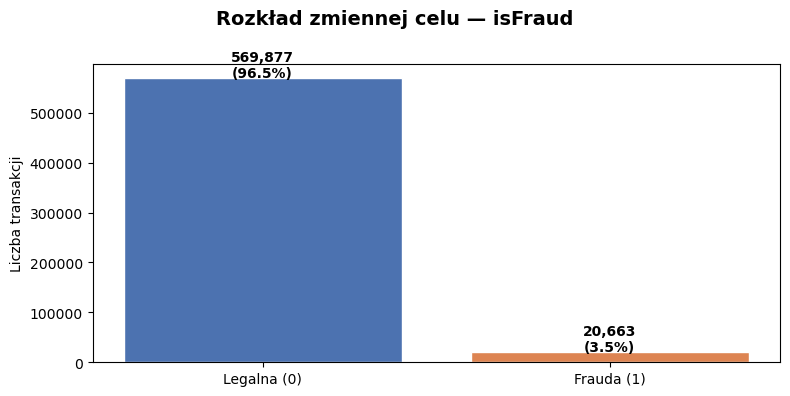

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("Rozkład zmiennej celu — isFraud", fontsize=14, fontweight="bold")

counts = train["isFraud"].value_counts()
bars = ax.bar(["Legalna (0)", "Frauda (1)"], counts.values,
              color=["#4c72b0", "#dd8452"], edgecolor="white")
ax.set_ylabel("Liczba transakcji")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"{val:,}\n({val/len(train)*100:.1f}%)",
            ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

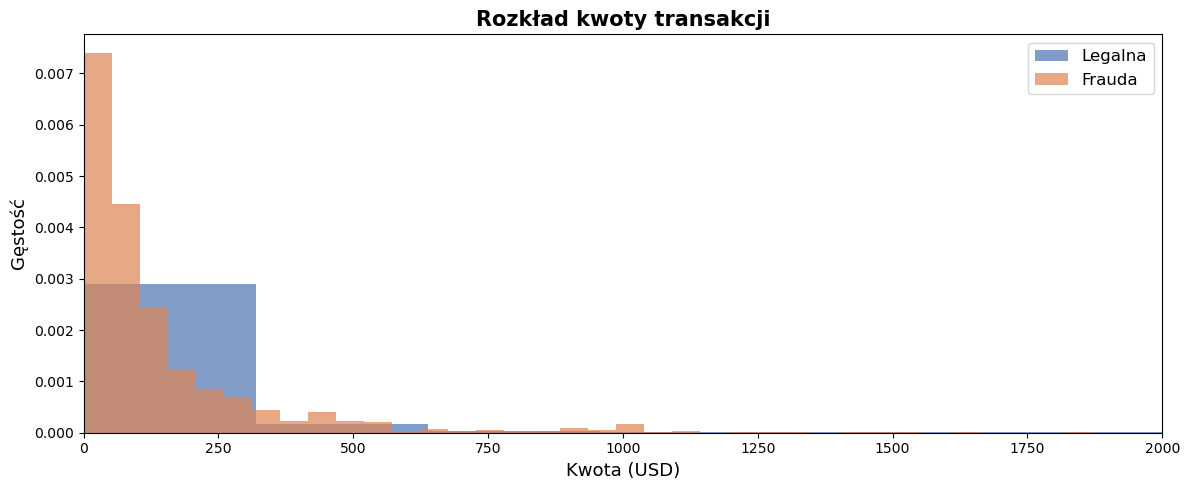

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

fraud   = train[train["isFraud"] == 1]["TransactionAmt"]
legalna = train[train["isFraud"] == 0]["TransactionAmt"]

ax.hist(legalna, bins=100, color="#4c72b0", alpha=0.7, label="Legalna", density=True)
ax.hist(fraud,   bins=100, color="#dd8452", alpha=0.7, label="Frauda",  density=True)
ax.set_xlabel("Kwota (USD)", fontsize=13)
ax.set_ylabel("Gęstość", fontsize=13)
ax.set_title("Rozkład kwoty transakcji", fontsize=15, fontweight="bold")
ax.set_xlim(0, 2000)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

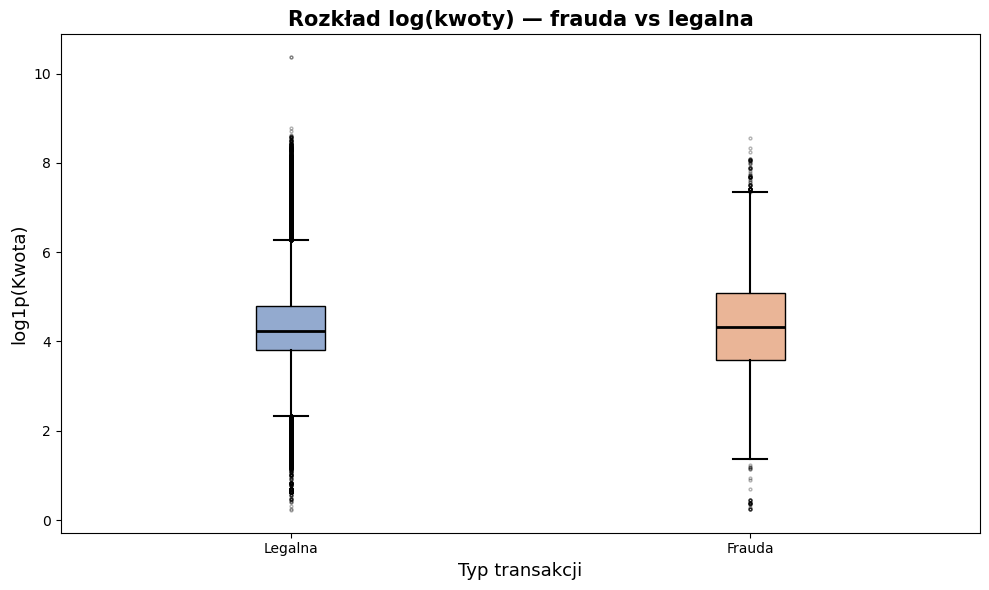

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

data_box = [np.log1p(legalna), np.log1p(fraud)]
bp = ax.boxplot(data_box, patch_artist=True, labels=["Legalna", "Frauda"],
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.3))
bp["boxes"][0].set_facecolor("#4c72b099")
bp["boxes"][1].set_facecolor("#dd845299")

ax.set_ylabel("log1p(Kwota)", fontsize=13)
ax.set_xlabel("Typ transakcji", fontsize=13)
ax.set_title("Rozkład log(kwoty) — frauda vs legalna", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

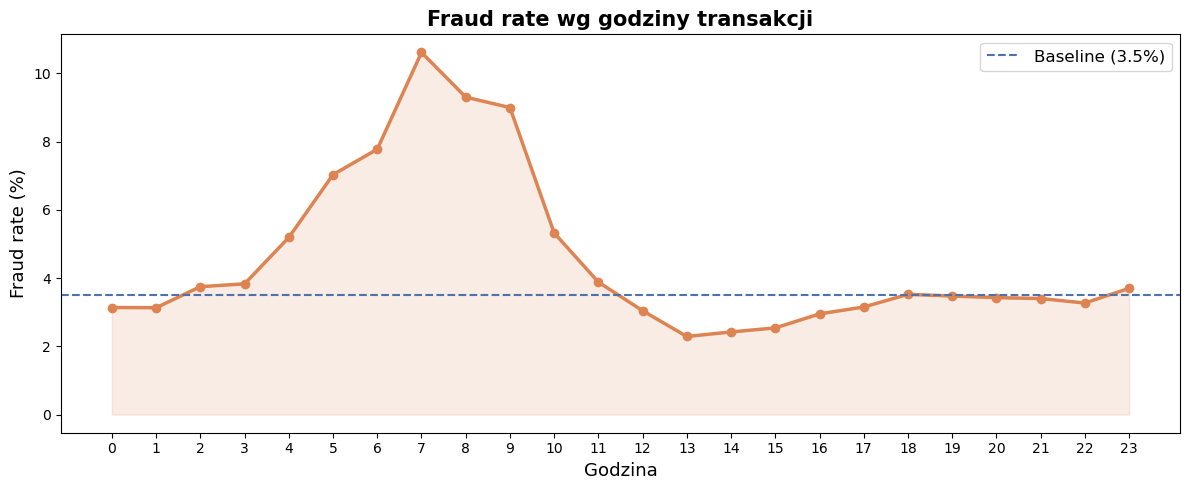

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

fraud_by_hour = train.groupby("hour")["isFraud"].mean() * 100

ax.plot(fraud_by_hour.index, fraud_by_hour.values,
        color="#dd8452", linewidth=2.5, marker="o", markersize=6)
ax.fill_between(fraud_by_hour.index, fraud_by_hour.values,
                alpha=0.15, color="#dd8452")
ax.axhline(train["isFraud"].mean() * 100, color="#4c72b0",
           linewidth=1.5, linestyle="--", label=f"Baseline ({train['isFraud'].mean()*100:.1f}%)")
ax.set_xlabel("Godzina", fontsize=13)
ax.set_ylabel("Fraud rate (%)", fontsize=13)
ax.set_title("Fraud rate wg godziny transakcji", fontsize=15, fontweight="bold")
ax.set_xticks(range(0, 24))
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

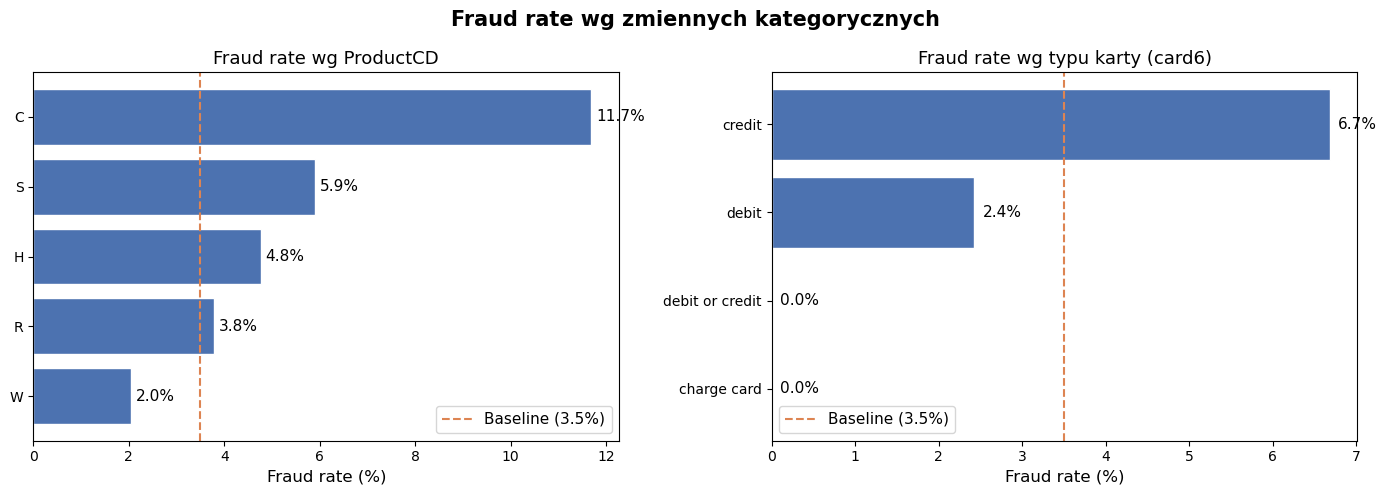

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fraud rate wg zmiennych kategorycznych", fontsize=15, fontweight="bold")

# Odtwarzamy oryginalne wartości z train_transaction bo już zakodowaliśmy
product_fraud = train_transaction.groupby("ProductCD")["isFraud"].mean() * 100
product_fraud = product_fraud.sort_values(ascending=True)

card6_fraud = train_transaction.groupby("card6")["isFraud"].mean() * 100
card6_fraud = card6_fraud.sort_values(ascending=True)

baseline = train["isFraud"].mean() * 100

# ProductCD
bars = axes[0].barh(product_fraud.index, product_fraud.values,
                    color="#4c72b0", edgecolor="white")
axes[0].axvline(baseline, color="#dd8452", linewidth=1.5,
                linestyle="--", label=f"Baseline ({baseline:.1f}%)")
axes[0].set_xlabel("Fraud rate (%)", fontsize=12)
axes[0].set_title("Fraud rate wg ProductCD", fontsize=13)
axes[0].legend(fontsize=11)
for bar, val in zip(bars, product_fraud.values):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=11)

# card6
bars2 = axes[1].barh(card6_fraud.index, card6_fraud.values,
                     color="#4c72b0", edgecolor="white")
axes[1].axvline(baseline, color="#dd8452", linewidth=1.5,
                linestyle="--", label=f"Baseline ({baseline:.1f}%)")
axes[1].set_xlabel("Fraud rate (%)", fontsize=12)
axes[1].set_title("Fraud rate wg typu karty (card6)", fontsize=13)
axes[1].legend(fontsize=11)
for bar, val in zip(bars2, card6_fraud.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=11)

plt.tight_layout()
plt.show()

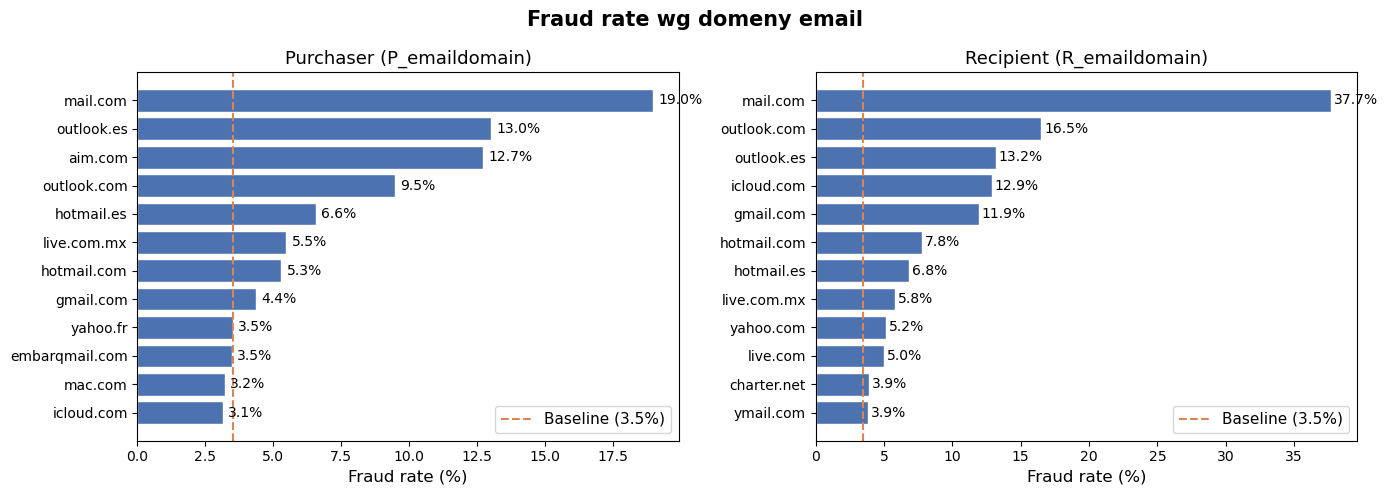

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fraud rate wg domeny email", fontsize=15, fontweight="bold")

baseline = train["isFraud"].mean() * 100

for ax, col, title in zip(axes,
    ["P_emaildomain", "R_emaildomain"],
    ["Purchaser (P_emaildomain)", "Recipient (R_emaildomain)"]):

    email_fraud = train_transaction.groupby(col)["isFraud"].agg(
        fraud_rate=("mean"),
        count=("count")
    ).reset_index()
    email_fraud["fraud_rate"] *= 100
    # Tylko domeny z min. 100 transakcji żeby uniknąć szumu
    email_fraud = email_fraud[email_fraud["count"] >= 100]
    email_fraud = email_fraud.sort_values("fraud_rate", ascending=True).tail(12)

    bars = ax.barh(email_fraud[col], email_fraud["fraud_rate"],
                   color="#4c72b0", edgecolor="white")
    ax.axvline(baseline, color="#dd8452", linewidth=1.5,
               linestyle="--", label=f"Baseline ({baseline:.1f}%)")
    ax.set_xlabel("Fraud rate (%)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=11)
    for bar, val in zip(bars, email_fraud["fraud_rate"]):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()